# Using Memory-Based State Estimators

In [214]:
#| hide
from nbdev import show_doc
import math

# Introduction

In this tutorial, we show how to use a series of increasingly complex memory graphs as the basis for Bayesian updates to a belief about the state of an external environment.

In the simplest memory graph,  'Sequence Memory', we model the memorization of an exact sequence of percepts through the encoding of percepts into memory traces (the graph nodes). We will show how this memory graph can be used to establish the probability that an external environment has returned to the exact state or sequence of states that produced the memorized sequence.

We add a level of complexity in 'Short-Term Memory', which models the 'fading' of information encoded in memory traces. We will show how this fading is comparable to forming a coarse-grained model of the world, making state estimation on the memory graph more robust to noisy signals.

'Long-Term Memory' builds further complexity by modeling (1) how the surprise of each percept mediates the fading rate of the memory trace to which it is encoded and (2) how 're-activation' of a memory trace consolidates the memory by slowing the fading rate of that trace. We will show how this allows the memory graph to prioritize the retention and re-activation of relevant memory traces, setting the stage for learning efficient representations of the external environment

Finally, with 'Associative Memory', we model the plasticity of memory traces upon re-activation. We will show how this plasticity allows the memory graph to learn and use efficient represetations of the external environnment for estimating the current state of that environment.

# Background - Series Recognition

Throughout this tutorial, we will use an experimental paradigm from psychology called "Series Recognition" to illustrate the functionality of each memory graph and the aspects of memory which it is said to model. In a Series Recognition task, a human or animal subject is presented with a series of items (i.e. a list). After a period of time known as a 'retention interval', the subject is presented with another item ('probe') and asked to identify whether or not that item was in the recently preseneted list. In cases where the probe matches an item from the recently presented list ('target'), the probability that both humans and animals answer correctly depends both on the position of the target in the list (e.g. first, second, fifth, last, etc.) and the length of the retention interval. Subjects are more likely to accurately recognize items presented earlier ('primacy effect') and items presented toward the end of the list ('recency effect') than items in the middle. For short retention intervals, the recency effect is much stronger than the primacy effect; as the retention interval increases, the recency effect reduces to the point of vanishing while the primacy effect remains consistent or increases. 

This interaction is widely regarded as evidence of a process of memory traces (sometimes 'stimulus traces') in short-term memory either being forgotten or transferred to long-term memory. We will use simulated environments that emulate a Series Recognition task to illustrate how each kind of memory graph builds toward a system of memory that both reproduces these effects and also learns efficient representations of the environment that can be used to make predictions about the future.

# Sequence Memory

With the "Sequence Memory" memory graph, we introduce the key concepts of memory-based state estimation. These key concepts are (1) The Memory-Environment Interface, (2) The Stationary Hypothesis, (3) Memory Traces, and (4) Bayesian Filtering. We will show that with these concepts, Sequence Memory can be usefully applied for state estimation in certain contrived environments.

## The Memory-Environment Interface

In the general Projective Simulation framework, an agent is said to interact with its environment through a percept-action loop. In this loop, the environment has a state which is updated as a function of the agent's action. This new environment state produces a percept, and the agent then updates its own state as a function of this percept before producing a new action. Because we are particularly interested in the *embodied* nature of agency, we think of that part of the agent which 'receives' the percept and 'transmits' the action as the agent-environment interface.

In this work, we consider a memory graph as a component of such an agent - a component that may form the basis of an Episodic and Compositional Memory. This memory graph takes as input the same percept as the agent and updates its state likewise. Because we do not explicitly model the production of an action by the agent here, we consider the memory-environment interface to be identical the agent-environment *sensory* interface. An important aspect of our memory graphs is that they decompose a percept into constituent parts - one can think of each percept 'category' being converted to the state of a corresponding sensor in the memory-environment interface.

To define a memory-graph, then, the first thing one must define is the number of sensors in the memory-environment interface and the number of states each sensor can take. This information is passed to the Sequence_Memory constructor as the argument 'category_sizes'. We will cover the other arguments to Sequence_Memory next.

In [215]:
from projective_simulation.ECMs.state_estimators import Sequence_Memory

In [216]:
show_doc(Sequence_Memory)

---

[source](https://github.com/{user}/projective_simulation/blob/master/projective_simulation/ECMs/state_estimators.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### Sequence_Memory

>      Sequence_Memory (category_sizes:list[int], memory_capacity:int,
>                       memory_bias:float, stationary_expectations:numpy.ndarray
>                       [typing.Any,numpy.dtype[numpy.float64]]=None, sensory_pr
>                       edictions:numpy.ndarray[typing.Any,numpy.dtype[numpy.flo
>                       at64]]=None, belief_prior:numpy.ndarray[typing.Any,numpy
>                       .dtype[numpy.float64]]=None, transition_predictions:nump
>                       y.ndarray[typing.Any,numpy.dtype[numpy.float64]]=None,
>                       timer:int=0, capacity_overflow_method:str='stop
>                       encoding', data_record:list[str]=[],
>                       record_until:int=-1,
>                       stationary_transition_method:str='first')

*Memory-based Bayesian filter that encodes a sequence of percepts as memory traces.
Each memory trace is a hypothesis about the environment, and the agent can transition between non-memory and memory hypotheses. 
Memory traces are encoded by dynamic modification of transition function and observation function.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| category_sizes | list |  | Number of states for each sensor/percept category. |
| memory_capacity | int |  | Number of memory-based hypotheses. |
| memory_bias | float |  | Probability of transitioning from non-memory to memory hypothesis space. |
| stationary_expectations | ndarray | None | Expectation of sensory states in stationarity. Default to uniform distributions for each sensor. |
| sensory_predictions | ndarray | None | Sensory hypotheses matrix. If None, initialized to uniform. |
| belief_prior | ndarray | None | Initial belief priors. If None, all prior on non-memory hypothesis. |
| transition_predictions | ndarray | None | Hypothesis transition matrix. |
| timer | int | 0 | Starting memory time index. |
| capacity_overflow_method | str | stop encoding | 'loop' or 'stop encoding'. |
| data_record | list | [] | List of variable names to log each time step. Accepts "all". |
| record_until | int | -1 | Number of steps to prepare for data logging. Negative disables recording. |
| stationary_transition_method | str | first | 'encoded', 'first', or 'learned'. |

## The Stationary Hypothesis

The goal of a memory graph is to build a predictive model of the environment for an agent that has no prior knowledge about the structure of the environment, i.e. the states of the environment that exist and how they relate to each other and to the agent's percepts. To achieve this, it is helpful to assume the agent 'inherits' some knowledge about general properties of its environment; what we might call *implicit biases*. In our case, we assume that the agent inherits knowledge of the overall probability that any given state in the environment yields a given state for any sensor - or at least a rough approximation thereof. This knowledge is represented in a memory graph by what we call the "stationary hypothesis". To define the stationary hypothesis, one must pass a 1D numpy array to the argument stationary_expectations of the Sequence_Memory constructor that contains these probabilities. These probabilites must be ordered such that the first $N_1$ elements represent the probability distribution over the $N_1$ possible states of the first sensor, as defined by category_sizes; the next $N_2$ elements give the probability distribution over the possible states of the second sensor, and so-on and so-forth for all sensors indicated by the length of the category_sizes list. An example is provided below.

In [217]:
import numpy as np

In [218]:
#Define a memory-environment interface with two sensors, each of which can take two states
category_sizes = [2,2]

#Define stationary_expectations for the above memory-environment interface.
#The resulting implicit bias is that both states of the first sensor are equally common, 
#but the first state of the second sensor occurs 9x more frequently, overall, than the second state.
stationary_expectations_good = np.array([0.5,0.5,0.9,0.1])

#Some examples of invalid stationary_expectations. 
#These would raise Value Errors if initialization of Sequence_Memory was attempted
stationary_expectations_bad1 = np.array([0.5,0.5,0.8,0.1]) #expectations on the second sensor do not yield a valid probability distribution
stationary_expectations_bad2 = np.array([0.5,0.5,0.6,0.3,0.1]) #the total number of possible states does not align with category_sizes

In [219]:
#Initialize Valid Sequence Memory
toy_sequence_memory_graph = Sequence_Memory(
    category_sizes=category_sizes,
    stationary_expectations=stationary_expectations_good,
    memory_capacity=5, #to be explained next
    memory_bias = 0.05 #to be explained subsequently
)
toy_sequence_memory_graph

## Memory Traces

### Encoding Percepts and Sensory Predictions

To begin, the only information a memory graph has about the environment comes from its stationary hypothesis - but it can acquire more information by storing information about its percepts into a **memory trace**. The Sequence Memory graph will store the first $C$ many percepts it receives to memory traces, where $C$ is its *memory capacity*. The percept is initially stored as a set of **one-hot encodings** in the same structure as the expectations encoded by the stationary hypothesis. That is to say, as a 1D array where the first $N_1$ elements are a one-hot encoding of the state of the first percept category/sensor, so-on and so-forth for all percept categories/sensors. 

The combination of the memory graph's memory traces and its stationary hypothesis form the memory graph's **hypothesis space** about its *situation* in the environment. We use *situation* to mean the set of world states (the joint state of the environment and the agent or memory graph) that yield the same effective future for the agent or memory graph's interface with the environment, i.e. the future percepts of the memory graph. For a Sequence Memory graph, one can think of a memory trace as representing the hypothesis that "my situation is the same as when the percept stored in this trace was encoded." The Stationary Hypothesis can be understood to represent the hypothesis "my situation is not the same as it was when the percepts stored in any of my memory traces were encoded." 

The percept information encoded in each of these hypotheses, then, can be understood as a prediction about the state of each sensor/percept category given that the hypothesis is true. In a Sequence_Memory instance, these predictions are stored in the *sensory_predictions* matrix. We can see in our toy instantiation that this matrix is initialized with predictions for each of the five memory traces it has the capacity to encode that are identical to the predictions of its stationary hypothesis.

In [220]:
toy_sequence_memory_graph.sensory_predictions
#The first five rows of this matrix give the sensory predictions of the five memory traces available to the memory graph.
#The last row gives the sensory predictions of the stationary hypothesis.
#Initially, these are all identical.

array([[0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1]])

If we pass a percept to the Sequence Memory graph using its *sample* method, we can see how the first memory trace changes to a one-hot encoding of the percept.

In [221]:
percept1 = np.array([1,0])
toy_sequence_memory_graph.sample(percept1)
toy_sequence_memory_graph.sensory_predictions

array([[0. , 1. , 1. , 0. ],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1],
       [0.5, 0.5, 0.9, 0.1]])

The default Sequence Memory stops encoding percepts to memory traces after it has used all available traces. We discuss alternative methods in the "further modelling considerations" section.

### Encoding Hypothesis Transitions and Memory Bias

Each of the memory graph's hypotheses store information about sensor state probabilities, give the hypothesis is true, and about the proability that any other hypothesis will be true when the *next* percept is recieved. For a Sequence Memory Graph, this infomormation can be specified on initialization and does not change. The predicted probability of transitioning from one memory trace hypothesis to another is always one if the second memory trace was encoded immediately after the first and zero otherwise. This reflects another implicit bias of the Sequence Memory graph: the assumption that situations follow a deterministic cycle (this assumption will be relaxed in other memory graphs). We can see that these predictions are already set up in the toy Sequence Memory's *transition_predictions*.

In [222]:
toy_sequence_memory_graph.transition_predictions

array([[0.  , 1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 1.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.05, 0.  , 0.  , 0.  , 0.  , 0.95]])

What about the transition predictions of the stationary hypothesis, given by the last row of the matrix? These are defined by the *memory bias*, the last required argument for initializing a Sequence Memory instance. One can see that for a Sequence Memory graph, the memory bias gives the probability with which the stationary hypothesis predicts the memory graph's next situation will be the same as it's situation when its first memory was encoded. This probability reflects an implicit bias of the Sequence Memory graph regarding the assumed size of the environment's state space. In the case of our toy instance, for example, we can determine that the memory bias implies an expectation that the memory graph will move through a deterministic cycle of twenty-five situations. Why? The memory graph can encode five situations to memory, then must rely on its stationary hypothesis to represent the rest. If there are twenty such remaining situations, and all the memory graph 'knows' if its stationary hypothesis is true is that it is in one of those situations, then the probablility that it is in the situation that precedes the situation represented by its first memory trace is 0.05. It can not transition to situations represented by other memory traces because it remembers the situations that preceded each and - if its stationary hypthesis is true - knows that it is not in any of those situations.

## Bayesian Filtering

The set of implicit biases used to define a Sequence Memory graph are quite strong - and likely not particularly useful for real embodied agents - but the resulting simplicity is useful for demonstrating and understanding the core mechanisms of all memory graphs: Bayesian filtering. The goal of Bayesian filtering is to establish a **belief state**, i.e. a probability distribution over a set of exhaustive and mutually exclusive hypotheses, and to update this belief state with each new observation. Here, observations take the form of percepts/sensory states. To illustrate how it works, we will initialize a new Sequence Memory instance and look at how it behaves in an environment we call the List Sequencer.



### Setting up a List Sequencer Environment

The List Sequencer produces two kinds of percepts: "list items" and "timeouts". During a timeout, all percept categories are set to state '0'. During the presentation of a list, all percept category states are non-zero. The user can define how many percept categories there are (list item size) and the number of states a percept category can take when a list item is presented. The number of sequential presented list items in each list is fixes, while the length of each timeout period between lists is drawn from a binomial distribution. This set-up serves as the foundation for simulated the classic series recognition task, which we explore in another tutorial. For now, we will examine only how memory graphs - starting with Sequence Memory - behave when presented with the percepts generated by the list sequencer. Let's look at a simple example of such a percept sequence.

In [223]:
from projective_simulation.envs.factorized_POMDPs import List_Sequencer

In [224]:
show_doc(List_Sequencer)
#'series' is used interchangeably with 'list'

---

[source](https://github.com/{user}/projective_simulation/blob/master/projective_simulation/envs/factorized_POMDPs.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### List_Sequencer

>      List_Sequencer (item_size:int, item_category_size:int, series_length:int,
>                      reuse_items:bool=True, stimulus_duration:int=1,
>                      mean_timeout_interval:float=4,
>                      var_time_out_interval:float=2, num_series:int=3,
>                      seed:Optional[int]=None, enable_probe:bool=False)

*A factorized POMDP that produces a specific percept sequence that emulates classic series recognition tasks of human and animal memory*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| item_size | int |  | number of percept categories per item (K) |
| item_category_size | int |  | number of valid values per category (C), values are 1..C |
| series_length | int |  | items per series |
| reuse_items | bool | True | If true, items can be reused in different lists. Items are never reused for the same list |
| stimulus_duration | int | 1 | time steps for which an item (or probe stimulus) is presented |
| mean_timeout_interval | float | 4 | μ: desired mean timeout length (Binomial) |
| var_time_out_interval | float | 2 | σ²: desired variance (should be < μ for Binomial under-dispersion) |
| num_series | int | 3 | number of series to present |
| seed | Optional | None | random seed for reproducibility (use the same seed to reproduce) |
| enable_probe | bool | False | if True, adds a state to each percept category for a probe cue stimulus, enabling probe recognition |

In [225]:
#Set up a simple series List_Sequencer environment

#For the sake of an illustrative example, we intentionally select a seed that produces a short sequence in which the first list repeats
seed = 110

item_size = 1
item_category_size = 3
series_length = 3
num_series = 4
mean_timeout_interval = 2
var_timeout_intervel = 1

example_lists = List_Sequencer(
    item_size, 
    item_category_size, 
    series_length,
    mean_timeout_interval=mean_timeout_interval,
    var_time_out_interval=var_timeout_intervel,
    num_series=num_series,
    seed = seed
    )

example_lists.percept_sequence

array([[1],
       [3],
       [2],
       [0],
       [1],
       [2],
       [3],
       [0],
       [0],
       [3],
       [2],
       [1],
       [0],
       [0],
       [1],
       [3],
       [2]])

### Simulating A Memory Graph

Now that we have a percept sequence, we can simulate the memory graph observing each percept. Let's simulate a sequence memory that only has enough capacity to remember the first list.

In [226]:
#~~Set up Sequence Memory parameters~~
percept_category_sizes = [item_category_size + 1] #add one state for timeout

#we give the true stationary distribution of percept category states in the generating environment to the sequence memory as its stationary expectations
#We get this by taking the matrix product of the stationary state distribution and the observation matrix (probability of each sensor state given each env state)
stationary_expectations = example_lists.get_stationary_state_distribution() @ example_lists.factorized_observation_function
memory_capacity = series_length

#In this simple Sequence Memory example, it is possible to derive a 'correct' memory bias. 
#We will do so here to illustrate the concept, but in general the memory bias can be an approximation.
possible_lists = math.perm(item_category_size ** item_size, series_length) #K choose N (order matters, no replacement), where N is series_length and K is the number of possible items
avg_percepts_per_list = series_length + mean_timeout_interval
total_situations = possible_lists * avg_percepts_per_list
encodable_situations = memory_capacity
memory_bias = 1/(total_situations - encodable_situations)
#~~End parameter setup~~

#intilize Sequence_Memory
num_percepts = np.shape(example_lists.percept_sequence)[0]
example_seq_memory = Sequence_Memory(percept_category_sizes, memory_capacity, memory_bias,stationary_expectations)
example_seq_memory.prepare_data_storage(data_record = ["all"], record_until = num_percepts) #this will store the belief state at every time step

#Simulate
for i in range(num_percepts):
    percept = example_lists.percept_sequence[i,:]
    example_seq_memory.sample(percept)


Let us first look at the structure of the Sequence Memory graph after the simulation. Each row of the heatmaps below can be read as the conditional probability of some prediction (an observed sensory state, or the next situation) given the hypothesized situation. Note that the sensory predictions encode the first three percepts, and that there is a small probability of transitioning from the stationary hypothesis to the first memory hypothesis, given by the memory bias.

In [227]:
from projective_simulation.methods.visualization import plot_heatmap, memory_filter_performance
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

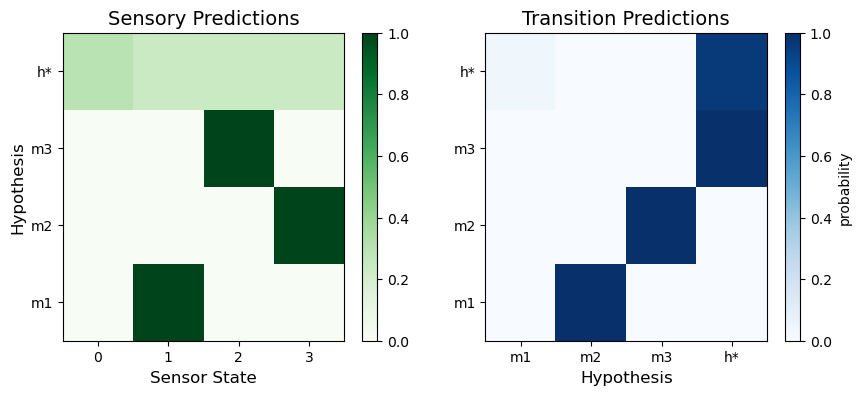

In [228]:
#Set Up Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#plot sensory predictions
plot_heatmap(
    example_seq_memory.sensory_predictions,
    title = "Sensory Predictions",
    xlabel = "Sensor State",
    xtick_labels= ["0","1","2","3"],
    ylabel = "Hypothesis",
    ytick_labels= ["m1", "m2", "m3", "h*"], #We will use 'h*' to denote the stationary hypothesis,
    color = "Greens",
    ax = ax1)

#plot transition predictions
plot_heatmap(
    example_seq_memory.transition_predictions,
    title = "Transition Predictions",
    xlabel = "Hypothesis",
    xtick_labels= ["m1", "m2", "m3", "h*"],
    ylabel = None,
    ytick_labels= ["m1", "m2", "m3", "h*"],
    colorbar_kwargs={"label": "probability"},
    color = "Blues",
    ax = ax2)

plt.tight_layout
pass

### The Belief State

Now let us look at the posterior belief state over the course of the simulation. In the heatmap below, each row contains the probability with which with the Sequence Memory believes each hypothesis to be true at a given time step, after observing the new percept. To the left of the heatmap is the percept sequence. To the right of the graph is the surprise of the Sequence Memory when the percept was recieved (more on this later)

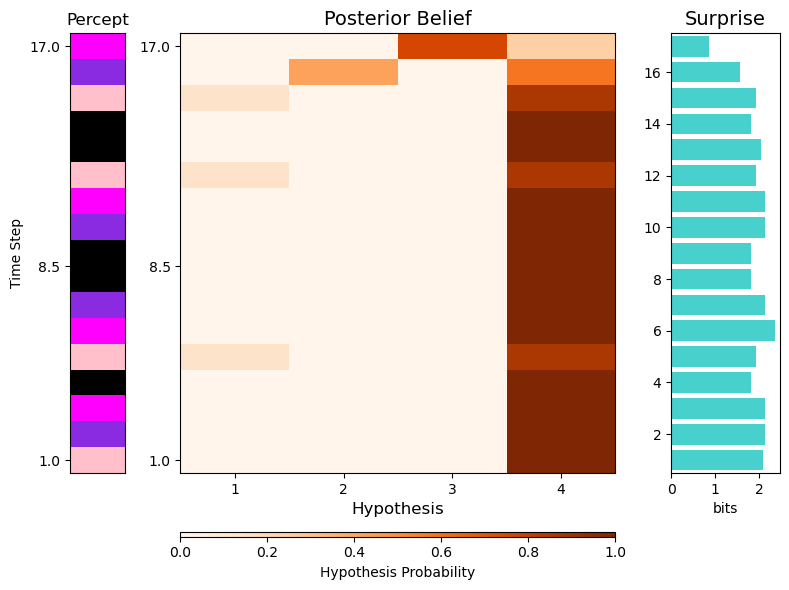

In [229]:
colormap = ('black', 'pink', 'fuchsia', 'blueviolet') #assign colors to each sensor state

memory_filter_performance(
    memory_data = example_seq_memory.data_dic, #data_dic is where memory graphs store the data indicated by the data_record argument
    observed_percepts=example_lists.percept_sequence,
    colormap = colormap,
    ) 

How does this work? The Sequence Memory begins with an initial belief that the probability of the stationary hypothesis is 1 (it has no encoded memories to provide an alternative hypothesis). When it recieves a percept, a memory graph performs a **Bayesian Update** by multiplying the prior probability of each hypothesis by the likelihood of the percept given that hypothesis is true, then renormalizing these products over the hypothesis space. This is the **posterior belief**. A new **prior belief** can then be computed by multiplying posterior probabilities of each hypothesis by the probabilites in the transition predictions.

The key idea of a Bayesian Filter, as just described, is that the history of percepts is not needed to maintainand accurate belief state (the vector of values that alternates between the prior belief and posterior belief), given that the hypotheses and their predictions provide an accurate hidden markov model of the environmental process.

The central motivation in creating the memory graphs present in this tutorial is to acknowledge that embodied agents do not intially possess such a model, but that they might still retain memory of past percepts as a means of building one. We aim to understand how such a model can be constructed accurately across a range of environments, despite limitations on memory capacity, and how agents might continue to act and survive in the world even as as such a model is being learned.

## The Value of Sequence Memory

In this tutorial so far, we have shown how Sequence Memory stores a percept to a memory trace by creating a one-hot encoding of that percept, where the structure of that one-hot encoding is determined by a representation of the possible states of the Memory-Environment Interface. The Sequence Memory encodes as many percepts to memory as it has capacity, and then stops - becoming static. Given appropriate implicit biases about the stationary distribution of sensor states and the number of situations that the memory graph lacks the capacity to encode, the belief state of Sequence Memory accurately reflects the probability that it has returned to the sequence of situations during which it was encoding memories.

The Sequence Memory graph is largely meant to demonstrate the probability theory foundations on which the next memory graphs are built, but it is not without value of its own. Similar systems may help embodied agents to imprint important patterns in early life, such as the presence of a parent, or the entrance to a central home/nest/den/hive/etc.

## Further Modelling Considerations
### Relaxing the definition of 'Situation'

In introducing Sequence Memory, transitions from the stationary hypothesis to any memory-based hypothesis other than the first were not allowed. This reflects a view of the world where situations, as represented by memory traces, are defined as sets of states with both identical future percepts *and* identical past percepts. If one relaxes the assumption that all environment states belonging to the same situtation have the same perceptual past, it opens the possibility of transitioning from an unremebered situtation to a situation represented by a memory trace other than the first. This can be modelled using Sequence Memory by setting the stationary_transition_method to "encoded" (allows transition to all encoded memories, as opposed the default "first"). Let us look at how this changes the posterior beliefs of a Sequence Memory given the same percept sequence as before

In [230]:
seq_memory2 = Sequence_Memory(
    percept_category_sizes, 
    memory_capacity, 
    memory_bias,
    stationary_expectations,
    stationary_transition_method = 'encoded')
seq_memory2.prepare_data_storage(data_record = ["all"], record_until = num_percepts) #this will store the belief state at every time step

#Simulate
for i in range(num_percepts):
    percept = example_lists.percept_sequence[i,:]
    seq_memory2.sample(percept)

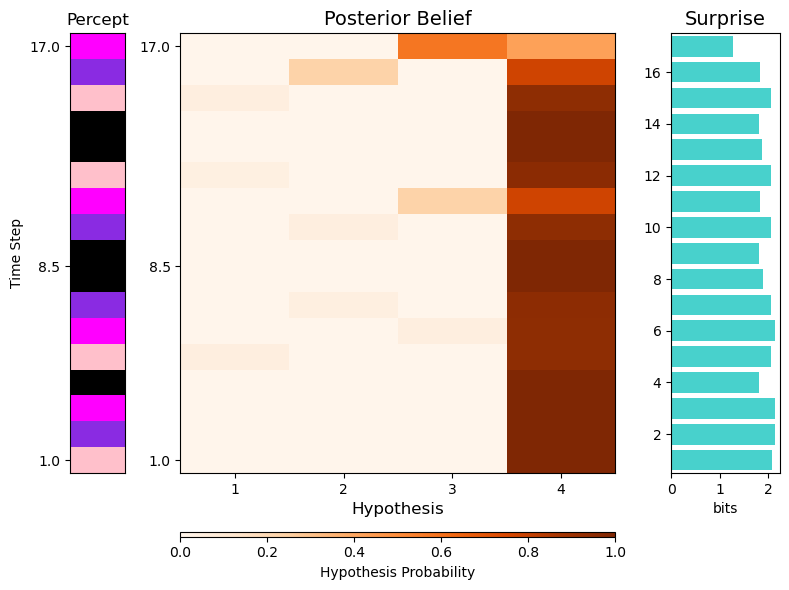

In [231]:
memory_filter_performance(seq_memory2.data_dic,example_lists.percept_sequence,colormap)

Posterior probability is now assigned to a memory trace any time the current percept matches the one encoded in that memory trace - even if preceding percepts do not match. As before, the posterior belief weight increases as a sequence of percepts matches a stored sequence. Note that the memory bias is divided across encoded memories, reducing the initial posterior belief probability when a matching percept is encountered.

In [232]:
print(np.round(seq_memory2.transition_predictions, decimals=3))

[[0.    1.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    0.    1.   ]
 [0.012 0.012 0.012 0.963]]


### Encoding recent vs. first percepts

One can also allow Sequence Memory to continue encoding new memories after its capacity has been reached by overwritin the oldest memory trace. This is done by setting the *capacity_overflow* method to 'loop'. However, this is the default setting for the next kind of memory graph, Short-Term Memory, which we introduce now. In general, we recommend using a Short-Term Memory graph to model memory of recent percepts, as opposed to early, formative percepts.

# Short-Term Memory

## When Sequence Memory Fails

Whether Sequence Memory is used to encoded recent or formative percepts, it uses one-hot encodings as sensory predictions; this requires that the perceptual futures of situations encoded by a memory trace must be *exactly identical*, not *probabilistically equivalent*. 

Consider how the posterior belief of a Sequence Memory graph behaves if noise is added to the example percept sequence used in the previous section.

In [233]:
#Add a noisy percept category to previous percept sequence
np.random.seed(1617031025)
noisy_percept_category_sequence = np.random.choice(a = 2, size = num_percepts) #randomly sample 0s and 1s
noisy_percept_sequence = np.concatenate((example_lists.percept_sequence, noisy_percept_category_sequence[:,np.newaxis]), axis = 1)
noisy_percept_sequence

array([[1, 1],
       [3, 1],
       [2, 1],
       [0, 1],
       [1, 0],
       [2, 0],
       [3, 1],
       [0, 0],
       [0, 1],
       [3, 1],
       [2, 1],
       [1, 0],
       [0, 1],
       [0, 1],
       [1, 1],
       [3, 1],
       [2, 0]])

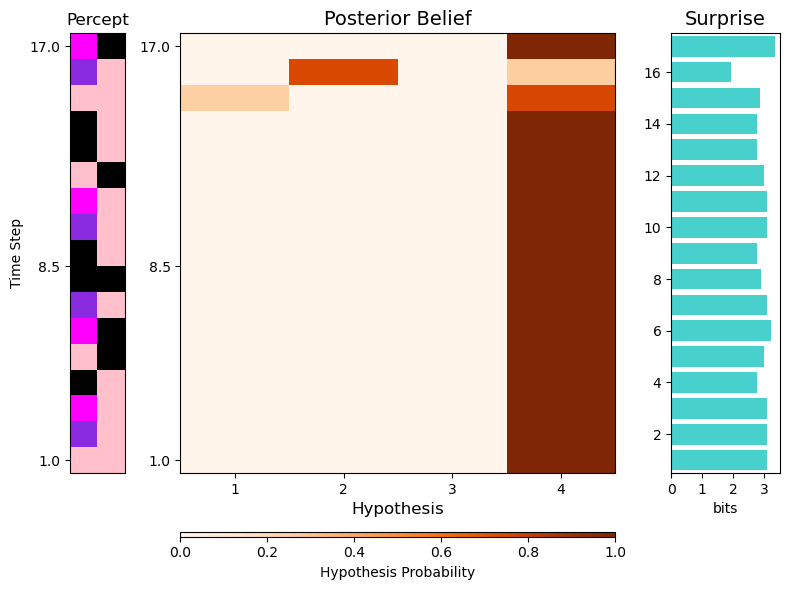

In [234]:
#Set Up Sequence Memory
new_percept_category_sizes = [4,2] #4 states of 1st sensor (from previous) and 2 states of 2nd sensor (noisy)
new_stationary_expectations = np.concatenate((stationary_expectations, np.array([0.5,0.5]))) #add stationary expectations for new percept category

seq_memory_noisy = Sequence_Memory(
    new_percept_category_sizes, 
    memory_capacity, 
    memory_bias,
    new_stationary_expectations,
    stationary_transition_method = 'first')

seq_memory_noisy.prepare_data_storage(data_record = ["all"], record_until = num_percepts)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    seq_memory_noisy.sample(percept)

#Visualize
memory_filter_performance(seq_memory_noisy.data_dic, noisy_percept_sequence, colormap)

Note that when the first percept category (lists) and the second percept category (noise) both match the percept encoded in a memory, it provides stronger evidence for the represented situation than when only one percept category existed. However, when the 'noisy' category fails to match a previously encoded percept, that memory trace is rejected as a viable hypothesis - even if the 'list' category has observed a matching sequence, as in time step 17.

This can be avoided if we move from a binary encoding of percept category states to a probability mass function that allows some probability of percept category states other than the one observed at the time of encoding. This is akin to saying that the situation represented by a memory trace may not always produce the same percept. But how to know what the proper probabilities are?

## Memory Trace Fading

In a Short-Term memory graph, the sensory predictions of a memory trace become more distributed over time. Specifically, we say the predictions 'fade' toward the stationary distribution from the initial one-hot encoding. One can think of this like the memory graph expanding the set of possible environment states that qualify as a given situation - at the cost of predictive specificity. In other words, Short-Term memory models a course graining of a world-model, where older memories represent more course-grained situations and newer memories represent more fine-grained situations.

Let's see what this looks like when compared to a Sequence Memory graph. We will go ahead and give both memory graphs a larger memory capacity and simulate for an equal number of steps.

In [235]:
from projective_simulation.ECMs.state_estimators import Short_Term_Memory

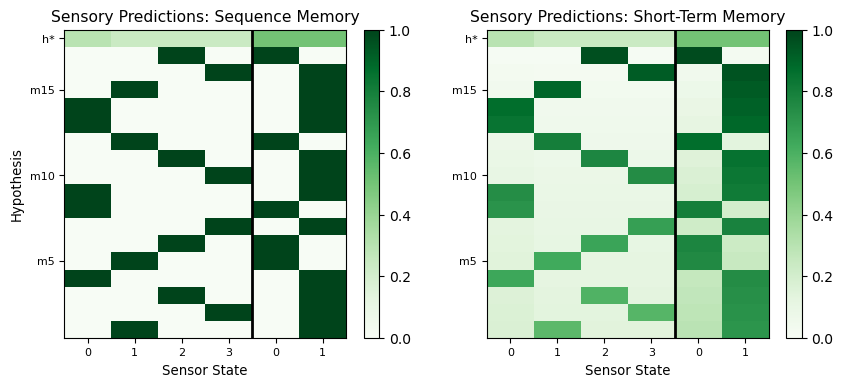

In [244]:
new_memory_capacity = num_percepts
new_memory_bias = memory_bias = 1/(total_situations - new_memory_capacity) #with a larger memory, we increase the memory bias

#intialize Sequence Memory
seq_memory_noisy2 = Sequence_Memory(
    new_percept_category_sizes, 
    new_memory_capacity, 
    new_memory_bias,
    new_stationary_expectations,
    stationary_transition_method = 'first',
    data_record = ['all'],
    record_until = num_percepts
)

#initialize Short-Term Memory
fading_rate = 0.05   #Controls how fast sensory predictions fade from one-hot to stationary
short_term_memory_noisy = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = new_memory_capacity, 
    memory_bias = new_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'first',
    data_record = ['all'],
    record_until = num_percepts
)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    seq_memory_noisy2.sample(percept)
    short_term_memory_noisy.sample(percept)

#Visualize Sensory Predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

##Sequence Memory Predictions
plot_heatmap(
    seq_memory_noisy2.sensory_predictions,
    title = "Sensory Predictions: Sequence Memory",
    xlabel = "Sensor State",
    xtick_labels= ["0","1","2","3","0","1"],
    ylabel = "Hypothesis",
    yticks = [4.5,9.5,14.5,17.5],
    ytick_labels= ["m5", "m10", "m15", "h*"],
    color = "Greens",
    label_scale = 0.8,
    ax = ax1,
    category_sizes = new_percept_category_sizes)

##Short-Term Memory Predictions
plot_heatmap(
    short_term_memory_noisy.sensory_predictions,
    title = "Sensory Predictions: Short-Term Memory",
    xlabel = "Sensor State",
    xtick_labels= ["0","1","2","3","0","1"],
    ylabel = None,
    yticks = [4.5,9.5,14.5,17.5],
    ytick_labels= ["m5", "m10", "m15", "h*"],
    color = "Greens",
    label_scale = 0.8,
    vmin = 0., 
    vmax = 1., #sets scale of colorbar
    ax = ax2,
    category_sizes = new_percept_category_sizes)

plt.tight_layout
pass

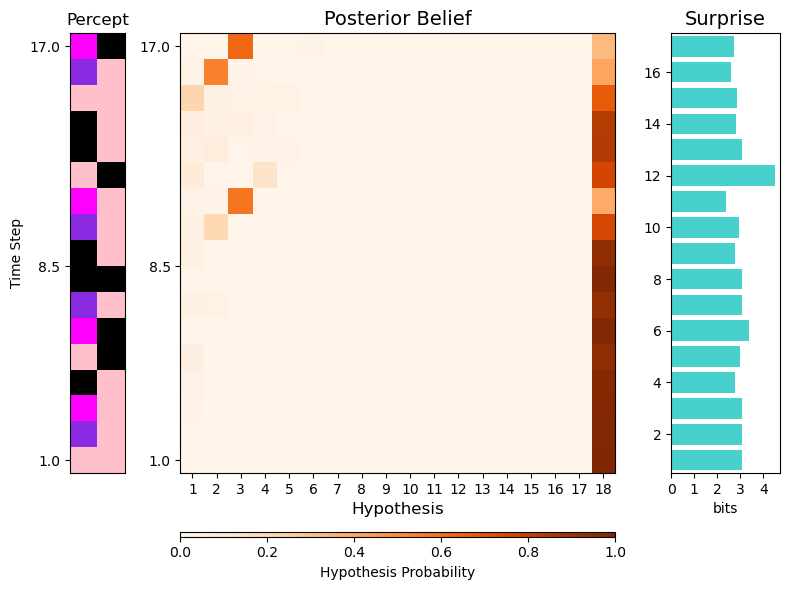

In [238]:
memory_filter_performance(short_term_memory_noisy.data_dic, noisy_percept_sequence, colormap)

We can see from these figures that when the first list repeats the old memory traces encoding that list, though somewhat faded, still "reactivate" as evidence accumlates that the new percept sequence matches the old one. We also some reactivation of memories throughout the simulation of memories that belong to sequences that are co-incidently similar - but not identical to to the first list.

## Re-evaluating the Memory Bias

In the previous simulation, we did not allow the Short-Term Memory graph to predict transitions from the stationary hypothesis to memory hypotheses other than the first, as is the default for Sequence Memory. However, as discussed in the 'Further Modelling Considerations' section of the Sequence Memory tutorial, this implicit bias makes less sense when the situations represented by memory traces provide a coarse grained model of the environmental states.

In the list_sequencer environment, for example, a previously seen list might appear after a different list or timeout interval than before. While recieving percepts from the repeated list, the memory graph's percept future is *probabilistically equivalent* to its percept future when it last saw the list - it is in the same situation. But, the percept histories of these list presentations are different. We want, then, to allow the memory graph to predict transitions from previously unexperienced situations, represented by the stationary hypothesis, to any situation represented by a memory trace. It becomes clear in this case why the memory bias is best understood as an approximation; as memories fade and yield increasingly coarse-grained representations of the situational landscape, it is impossible to know what new, unexperienced environmental states the memory trace comes to represent. This challenge is addressed to a degree by the Long-Term and Associative Memory graphs, but for now we will explore the benefits of even a roughly approximated memory bias.

Let us look at what happens when the memory_bias probability is divided across transitions to all encoded memory traces of Short-Term Memory, rather than assigned entirely to the first (or oldest) memory trace. We will first look at the transition predictions after only five time steps.

In [239]:
#Initialize new Short-Term Memory
short_term_memory_uniform_bias = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = new_memory_capacity, 
    memory_bias = new_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               #changed from previous STM
    data_record = ['all'],
    record_until = num_percepts
)

#Simulate first steps
for i in range(5): #we will inspect the transition matrix after a small number of steps, then a larger number
    percept = noisy_percept_sequence[i,:]
    short_term_memory_uniform_bias.sample(percept)

#Look at transition predictions of stationary hypthesis
np.round(short_term_memory_uniform_bias.transition_predictions[-1,:], decimals = 3) #predictions of stationary hypothesis are always in last row

array([0.015, 0.015, 0.015, 0.015, 0.015, 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.923])

We can see how the memory bias is divided across encoded memory traces. After simulating up the memory capacity, the probabilty of transition to a memory-based hypothesis is divided across all traces

In [240]:
#Simulate final steps
for i in range(5,num_percepts): #we will inspect the transition matrix after a small number of steps, then a larger number
    percept = noisy_percept_sequence[i,:]
    short_term_memory_uniform_bias.sample(percept)

#Look at transition predictions of stationary hypthesis
np.round(short_term_memory_uniform_bias.transition_predictions[-1,:], decimals = 3) #predictions of stationary hypothesis are always in last row

array([0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
       0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.923])

Let us see, then, how this new approach changes the posterior beleifs of the Short-Term Memory graph as it observed the percepts

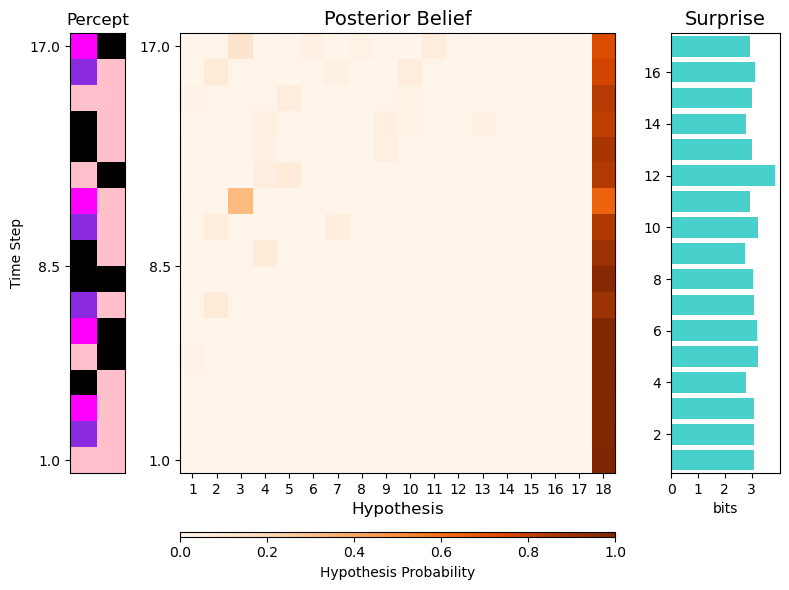

In [241]:
memory_filter_performance(short_term_memory_uniform_bias.data_dic, noisy_percept_sequence, colormap)

We can see a few things happening here. Because the probability of transitioning from the stationary hypothesis to the first memory-based hypothesis is smaller, these early memories are not as strongly reactivated by similar percept sequences. At the same time, memories of *other* lists are reactivated when *they* are similar to the most recent percept sequence. We can see (if we do some counting on the x-axis) that the final percept has reactivated both the memory trace associated with the final item of the first list and the second item of the third list - which, thanks to the noise, also has a similar history.

We are, however, using the same memory bias that was computing using the fine-grained representation assumptions of the Sequence Memory graph. Allowing that the coarser-grained representations given by the memory traces of a Short-Term memory graph may capture a greater proportion of the possible situations, we might consider a higher approximation for the memory bias.

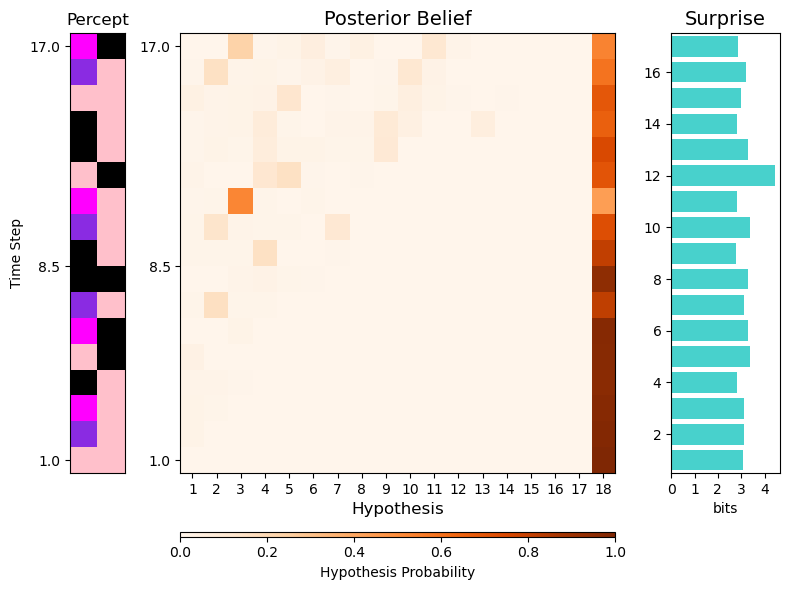

In [242]:
#Set up Short-Term Memory with bigger memory bias
bigger_memory_bias = 0.15
short_term_memory_uniform_bias2 = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = new_memory_capacity, 
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               #changed from previous STM
    data_record = ['all'],
    record_until = num_percepts
)

#Simulate
for i in range(num_percepts):
    percept = noisy_percept_sequence[i,:]
    short_term_memory_uniform_bias2.sample(percept)

memory_filter_performance(short_term_memory_uniform_bias2.data_dic,noisy_percept_sequence, colormap)

Naturally, we see higher reactivation across all memory traces. An "appropriate" memory bias is going to reflect how much memory traces fade before being re-encoded with a new percept and how large the capacity of the Short-Term Memory graph is relative the state space size of the environment it navigates. It is unlikely an embodied agent would inherit exact knowledge of such information, but even a very rough approximation can be of great use.

## The Value of Short-Term Memory

Consider an environmental state space that produces locally similar percept patterns. A Short-Term Memory graph may use recent percept sequences to make predictions about the future. Let's look at what happens if the set of lists we have used for percept sequences so far repeats and we give the Short-Term Memory just enough capacity to remember the last percept from the first presentation of the lists.

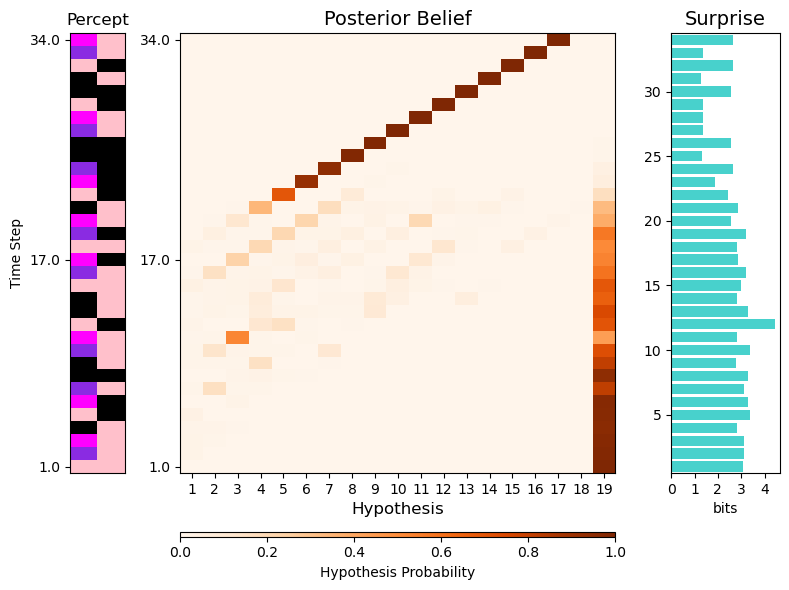

In [243]:
np.random.seed(1742031025)
#Create a repeating percept sequence
repeated_lists_percepts = np.concatenate((noisy_percept_sequence,noisy_percept_sequence), axis = 0)
#Add new noise to repeated percepts
repeated_lists_percepts[num_percepts:,1] = np.random.choice(2,size = num_percepts)
num_percepts_repeated = 2 * num_percepts

#intialize new STM
slightly_bigger_capacity = num_percepts + 1
short_term_memory_example = Short_Term_Memory(
    category_sizes = new_percept_category_sizes, 
    memory_capacity = slightly_bigger_capacity, #changed from previous STM
    memory_bias = bigger_memory_bias,
    fading_rate = fading_rate,
    stationary_expectations = new_stationary_expectations,
    stationary_transition_method = 'encoded',               
    data_record = ['all'],
    record_until = num_percepts_repeated #changed from previous STM
)

#Simulate
for i in range(num_percepts_repeated):
    percept = repeated_lists_percepts[i,:]
    short_term_memory_example.sample(percept)

memory_filter_performance(short_term_memory_example.data_dic, repeated_lists_percepts, colormap)


When the 'list' percept category begins to repeat, evidence increases for the hypothesis that the situation is the same as one represented by a memory trace that encode the earlier percept. Although these faded memory traces do not make accurate predictions about the noisy percept category (see the different surprise values in later time steps), they make very good predictions about the 'list' percept category. The faded memories, on balance, make better predictions than the stationary hypothesis, and the probabilities in the posterior belief shift accordingly - yielding better predictions overall.